In [123]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import astroML.stats
import random
import math
import sklearn.mixture as mix

In [47]:
start = 0 #clody day
pcc = 0.5 #cloudy|cloudy
psc = 0.5 #sunny|cloudy
pss = 0.9 #sunny|sunny
pcs = 0.1 #cloudy|sunny

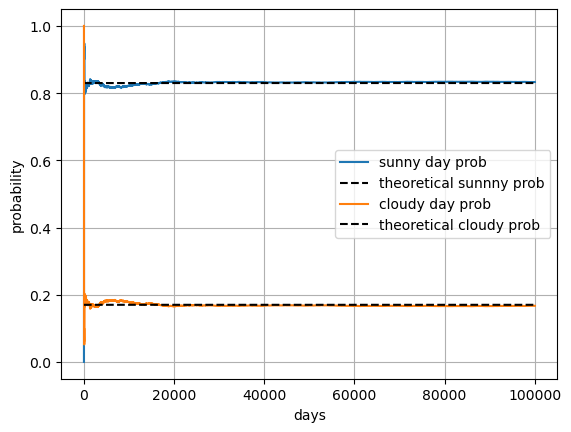

In [143]:
N = 100000
tod = start
s = 0 #count on sunny days
c = 0 #count on cloudy days
sunny_arr = []
cloudy_arr = []

for i in range(N):
    if tod == 0:
        tom = np.random.uniform(0,1,1)
        if tom < pcc: tod = 0
        if tom > pcc: tod = 1
        c = c+1
    else:
        tom = np.random.uniform(0,1,1)
        if tom < pcs: tod = 0
        if tom > pcs: tod = 1
        s = s+1
    sunny_arr.append(s/(i+1))
    cloudy_arr.append(c/(i+1))

plt.plot(np.linspace(0,N,N),sunny_arr,label='sunny day prob')
plt.plot(np.linspace(0,N,N), 0.83*np.ones(len(np.linspace(0,N,N))), '--', c='black', label='theoretical sunnny prob')
plt.plot(np.linspace(0,N,N),cloudy_arr,label='cloudy day prob')
plt.plot(np.linspace(0,N,N), 0.17*np.ones(len(np.linspace(0,N,N))), '--', c='black', label='theoretical cloudy prob')
plt.xlabel('days')
plt.ylabel('probability')
plt.legend()
plt.grid()

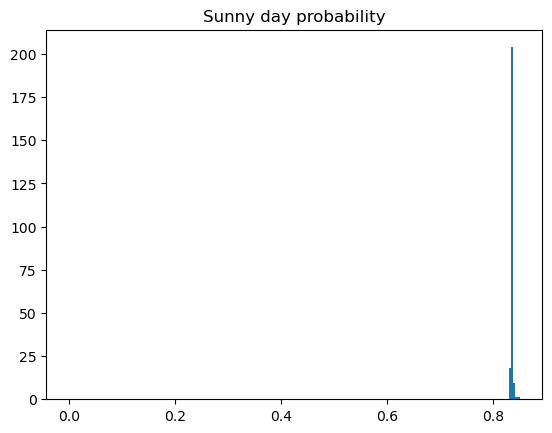

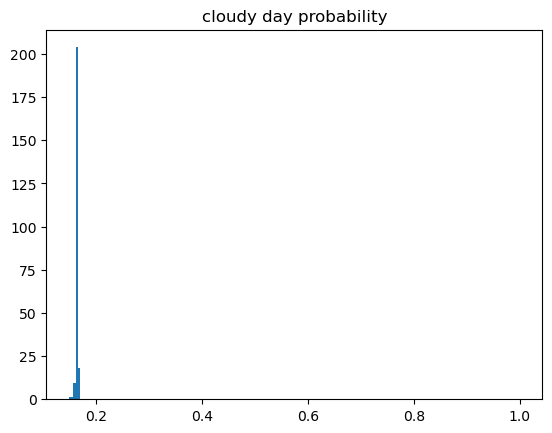

In [64]:
sunny_arr = np.array(sunny_arr)
cloudy_arr = np.array(cloudy_arr)

plt.hist(sunny_arr, bins=200, density=True)
plt.title('Sunny day probability')
plt.show()

a,b,c=plt.hist(cloudy_arr, bins=200, density=True)
plt.title('cloudy day probability')
plt.show()

In [128]:
print(np.median(sunny_arr), '+-', astroML.stats.sigmaG(sunny_arr))
print(np.median(cloudy_arr), '+-', astroML.stats.sigmaG(cloudy_arr))

0.8355618223400321 +- 0.0007167800012137604
0.16443817765996793 +- 0.0007167800012137604


## Burnings

In [139]:
s_cut = sunny_arr[2000:]
c_cut = cloudy_arr[2000:]

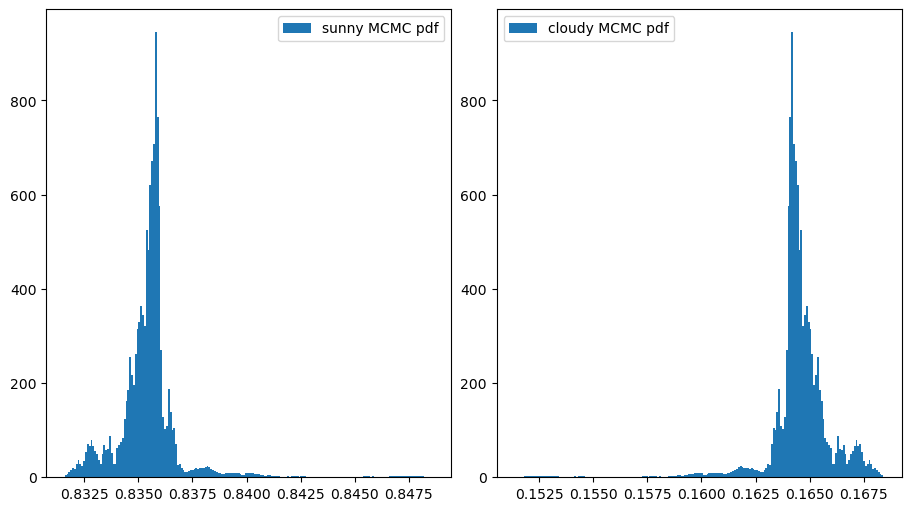

0.8355619989862264 +- 0.0007011943042159346
0.16443800101377348 +- 0.000701194304215914


In [140]:
fig, ax = plt.subplots(1, 2, figsize=(9, 5), constrained_layout=True)
ax[0].hist(s_cut, bins=200, density=True, label='sunny MCMC pdf')
ax[1].hist(c_cut, bins=200, density=True, label='cloudy MCMC pdf')
ax[0].legend()
ax[1].legend()
plt.show()
print(np.median(s_cut), '+-', astroML.stats.sigmaG(s_cut))
print(np.median(c_cut), '+-', astroML.stats.sigmaG(c_cut))

In [141]:
s_cut = sunny_arr[20000:]
c_cut = cloudy_arr[20000:]

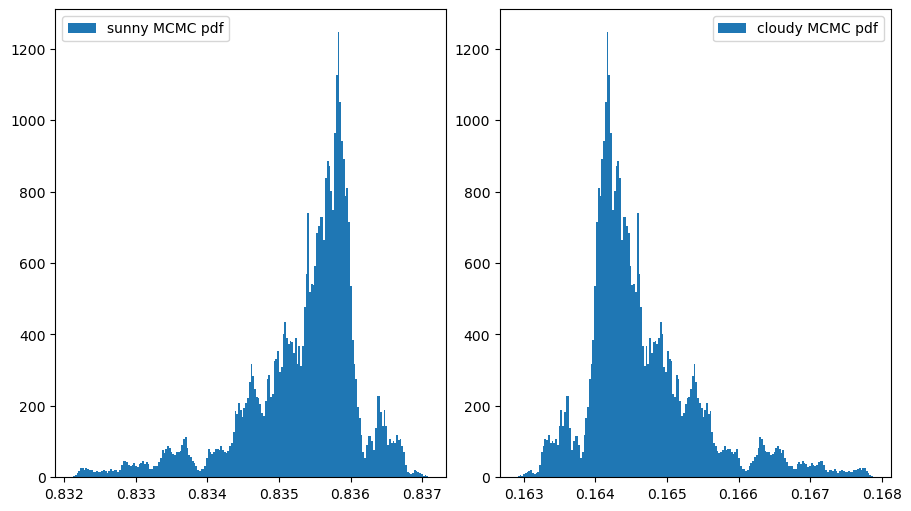

0.8355579870968758 +- 0.0006258099607166252
0.16444201290312424 +- 0.0006258099607165842


In [142]:
fig, ax = plt.subplots(1, 2, figsize=(9, 5), constrained_layout=True)
ax[0].hist(s_cut, bins=200, density=True, label='sunny MCMC pdf')
ax[1].hist(c_cut, bins=200, density=True, label='cloudy MCMC pdf')
ax[0].legend()
ax[1].legend()
plt.show()
print(np.median(s_cut), '+-', astroML.stats.sigmaG(s_cut))
print(np.median(c_cut), '+-', astroML.stats.sigmaG(c_cut))

In [85]:
## Execute this cell
## See https://github.com/twiecki/WhileMyMCMCGentlySamples/blob/master/content/downloads/notebooks/MCMC-sampling-for-dummies.ipynb
def sampler(data, samples=4, mu_init=.5, proposal_width=0.5, 
            plot=False, mu_prior_mu=0, mu_prior_sd=1.):
    mu_current = mu_init
    posterior = [mu_current]
    for i in range(samples):
        # suggest new position
        # changing the width of this distribution changes how big the jump is between trials.
        mu_proposal = norm(mu_current, proposal_width).rvs()

        # Compute likelihood by multiplying probabilities of each data point
        likelihood_current = norm(mu_current, 1).pdf(data).prod()
        likelihood_proposal = norm(mu_proposal, 1).pdf(data).prod()
        
        # Compute prior probability of current and proposed mu        
        prior_current = norm(mu_prior_mu, mu_prior_sd).pdf(mu_current)
        prior_proposal = norm(mu_prior_mu, mu_prior_sd).pdf(mu_proposal)
        
        p_current = likelihood_current * prior_current
        p_proposal = likelihood_proposal * prior_proposal

        # --- START OF CORRECTION ---
        # This block replaces the original 'p_accept' calculation
        if p_current == 0:
            # If the current probability is zero, accept if the proposal is not zero
            accept = p_proposal > 0
        else:
            # Otherwise, calculate p_accept and perform the standard check
            p_accept = p_proposal / p_current
            accept = np.random.rand() < p_accept

        # --- END OF CORRECTION ---
        
        if plot:
            plot_proposal(mu_current, mu_proposal, mu_prior_mu, 
                          mu_prior_sd, data, accept, posterior, i)
        
        if accept:
            # Update position
            mu_current = mu_proposal
        
        posterior.append(mu_current)
        
    return posterior

## Function to display
def plot_proposal(mu_current, mu_proposal, mu_prior_mu, 
                  mu_prior_sd, data, accepted, trace, i):
    from copy import copy
    trace = copy(trace)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4, figsize=(16, 4))
    fig.suptitle('Iteration %i' % (i + 1))
    xgrid = np.linspace(-3, 3, 5000)
    color = 'g' if accepted else 'r'
        
    # Plot prior
    prior_current = norm(mu_prior_mu, mu_prior_sd).pdf(mu_current)
    prior_proposal = norm(mu_prior_mu, mu_prior_sd).pdf(mu_proposal)
    prior = norm.pdf(xgrid,mu_prior_mu, mu_prior_sd)
    ax1.plot(xgrid, prior)
    ax1.plot([mu_current] * 2, [0, prior_current], marker='o', color='b')
    ax1.plot([mu_proposal] * 2, [0, prior_proposal], marker='o', color=color)
    ax1.annotate("", xy=(mu_proposal, 0.2), xytext=(mu_current, 0.2),
                 arrowprops=dict(arrowstyle="->", lw=2.))
    ax1.set(ylabel='Probability Density', 
            title='current: prior(mu=%.2f) = %.2f\nproposal: prior(mu=%.2f) = %.2f' % (mu_current, 
                                                                                       prior_current, 
                                                                                       mu_proposal, 
                                                                                       prior_proposal))
    
    # Likelihood
    likelihood_current = norm(mu_current, 0.01).pdf(data).prod()
    likelihood_proposal = norm(mu_proposal, 0.01).pdf(data).prod()
    y = norm.pdf(xgrid,loc=mu_proposal, scale=1)
    
    ax2.hist(data,alpha=0.5,density='True')
    ax2.plot(xgrid, y, color=color)
    ax2.axvline(mu_current, color='b', linestyle='--', label='mu_current')
    ax2.axvline(mu_proposal, color=color, linestyle='--', label='mu_proposal')
    
    ax2.annotate("", xy=(mu_proposal, 0.2), xytext=(mu_current, 0.2),
                 arrowprops=dict(arrowstyle="->", lw=2.))
    ax2.set(title='likelihood(mu=%.2f) = %.2f\nlikelihood(mu=%.2f) = %.2f' % (mu_current, 
                                                                              1e14*likelihood_current, 
                                                                              mu_proposal, 
                                                                              1e14*likelihood_proposal))
    
    # Posterior
    posterior_analytical = calc_posterior_analytical(data, xgrid, 
                                                     mu_prior_mu, 
                                                     mu_prior_sd)
    ax3.plot(xgrid, posterior_analytical)
    posterior_current = calc_posterior_analytical(data, mu_current, 
                                                  mu_prior_mu, mu_prior_sd)
    posterior_proposal = calc_posterior_analytical(data, mu_proposal, 
                                                   mu_prior_mu, mu_prior_sd)
    ax3.plot([mu_current] * 2, [0, posterior_current], marker='o', color='b')
    ax3.plot([mu_proposal] * 2, [0, posterior_proposal], marker='o', color=color)
    ax3.annotate("", xy=(mu_proposal, 0.2), xytext=(mu_current, 0.2),
                 arrowprops=dict(arrowstyle="->", lw=2.))
    
    ax3.set(title='posterior(mu=%.2f) = %.5f\nposterior(mu=%.2f) = %.5f' % (mu_current, 
                                                                            posterior_current, 
                                                                            mu_proposal, 
                                                                            posterior_proposal)) 
    if accepted:
        trace.append(mu_proposal)
    else:
        trace.append(mu_current)
    ax4.plot(trace)
    ax4.set(xlabel='iteration', ylabel='mu', title='trace')
    plt.tight_layout()

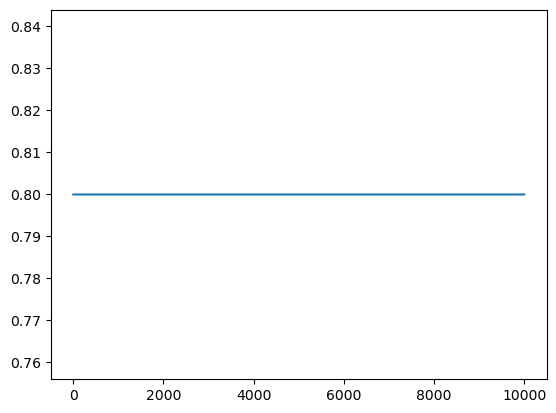

In [99]:
p_s = sampler(s_cut, samples=10000, mu_init=0.80, proposal_width=0.05, plot=False, mu_prior_mu=0.835, mu_prior_sd=0.1)
plt.plot(p_s)
plt.show()
#p_c = sampler(cloudy_arr, samples=1000, mu_init=0.1, proposal_width=0.1, plot=False, mu_prior_mu=0.17, mu_prior_sd=0.1)
#fig, ax = plt.subplots(1, 2, figsize=(9, 5), constrained_layout=True)
#ax[0].plot(p_s)
#ax[0].set(xlabel='sample', ylabel='sunny probability')
#ax[1].plot(p_c)
#ax[1].set(xlabel='sample', ylabel='cloudy probability')
plt.show()

# Do it many times

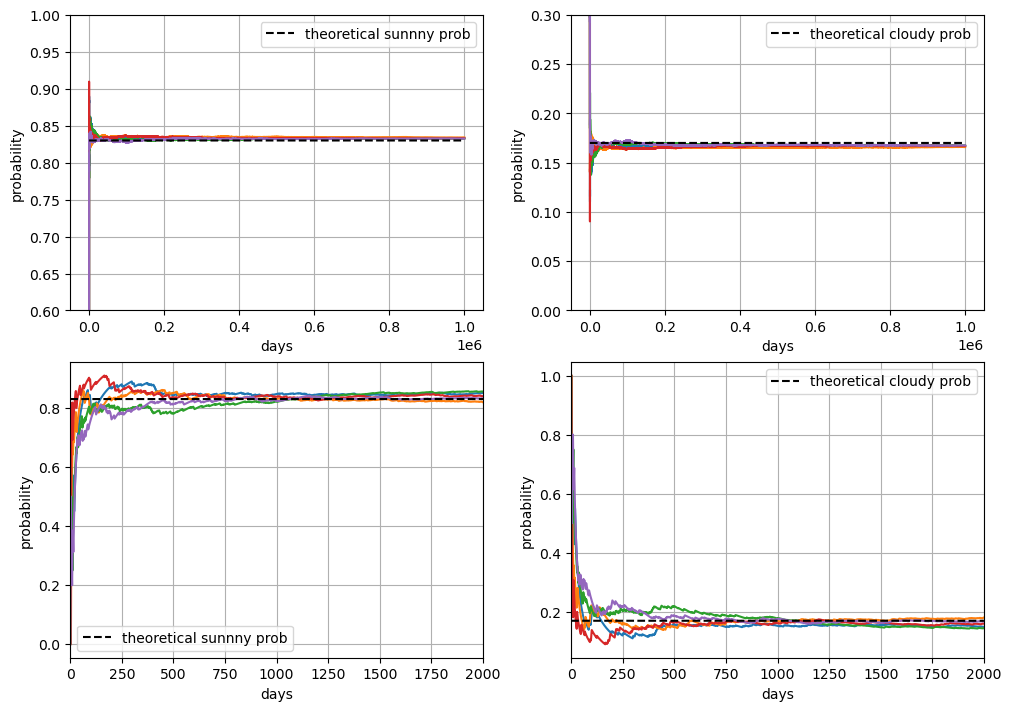

In [162]:
N = 1000000
fig, ax = plt.subplots(2,2, figsize=(10, 7), constrained_layout=True)

for j in  range(5):
    tod = start
    s = 0
    c = 0 
    sunny_arr = []
    cloudy_arr = []
    for i in range(N):
        if tod == 0:
            tom = np.random.uniform(0,1,1)
            if tom < pcc: tod = 0
            if tom > pcc: tod = 1
            c = c+1
        else:
            tom = np.random.uniform(0,1,1)
            if tom < pcs: tod = 0
            if tom > pcs: tod = 1
            s = s+1
        sunny_arr.append(s/(i+1))
        cloudy_arr.append(c/(i+1))
    
    [ax[a,0].plot(np.linspace(0,N,N),sunny_arr) for a in range(2)]
    [ax[b,1].plot(np.linspace(0,N,N),cloudy_arr) for b in range(2)]

[ax[a,0].plot(np.linspace(0,N,N), 0.83*np.ones(len(np.linspace(0,N,N))), '--', c='black', label='theoretical sunnny prob') for a in range(2)]
[ax[b,1].plot(np.linspace(0,N,N), 0.17*np.ones(len(np.linspace(0,N,N))), '--', c='black', label='theoretical cloudy prob') for b in range(2)]
#[ax[a,0].set_ylim(0.6, 1.)  for a in range(2)]
#[ax[b,1].set_ylim(0., 0.3)  for b in range(2)]
ax[0,0].set_ylim(0.6, 1.)
ax[0,1].set_ylim(0., 0.3)
ax[1,0].set_xlim(0., 2000) #burn-in zoom
ax[1,1].set_xlim(0., 2000) #bur-in zoom
[[ax[j,i].set_xlabel('days') for i in range(2)] for j in range(2)]
[[ax[j,i].set_ylabel('probability') for i in range(2)] for j in range(2)]
[[ax[j,i].legend() for i in range(2)] for j in range(2)]
[[ax[j,i].grid() for i in range(2)] for j in range(2)]
plt.show()